# AI Matching Connsistency Evaluation: OpenAI Comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Read Files

In [3]:
results = pd.read_csv('../data/results.csv')
openai_results = pd.read_csv('../data/openai_results.csv')

## Model Statistics

### Original

In [5]:
stats = results.groupby('model_name')['delta'].agg(['var', 'std', 'mean', 'min', 'max'])
stats = stats.sort_values('var')
print(stats)

                              var       std      mean       min       max
model_name                                                               
all-MiniLM-L6-v2         0.000939  0.030647  0.011156 -0.144222  0.239736
all-MiniLM-L12-v2        0.001961  0.044279  0.038028 -0.125257  0.301305
paraphrase-MiniLM-L6-v2  0.003412  0.058409  0.034707 -0.190418  0.495978


### OpenAI

In [7]:
openai_stats = openai_results.groupby('model_name')['delta'].agg(['var', 'std', 'mean', 'min', 'max'])
openai_stats = openai_stats.sort_values('var')
print(openai_stats)

                             var       std      mean       min       max
model_name                                                              
text-embedding-ada-002  0.000056  0.007499  0.002224 -0.016935  0.104449
text-embedding-3-small  0.000210  0.014488  0.002231 -0.025360  0.265213
text-embedding-3-large  0.000554  0.023548  0.000929 -0.040044  0.320138


## Model Flag Rate

* $No\;Flag \; = \; \Delta < 5\%$
* $Soft\;Flag \; = \; 5\% \leq \Delta < 15\%$
* $Hard\;Flag \; = \; \Delta \geq 15\%$

### Original

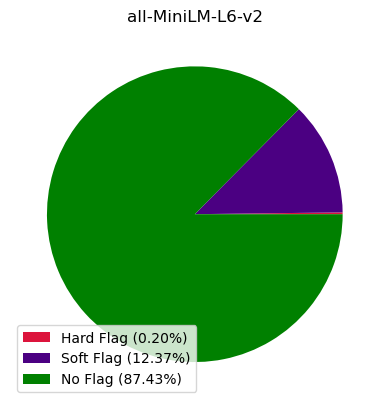

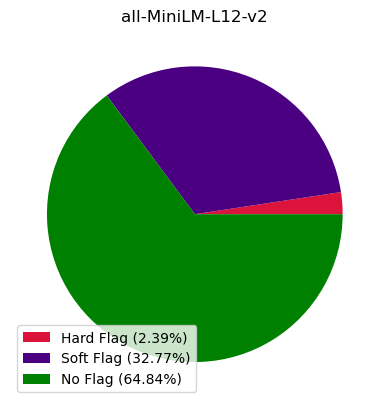

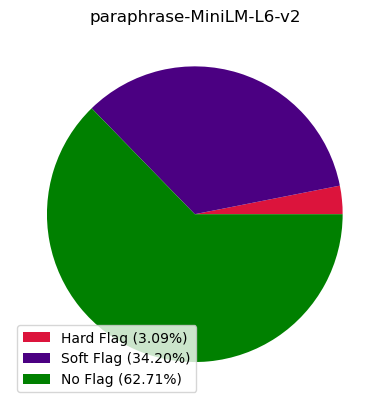

In [9]:
models = results['model_name'].unique().tolist()

for model in models:
    df = results[results['model_name'] == model]

    no_flag = len(df[df['flag'] == 0])
    soft_flag = len(df[df['flag'] == 1])
    hard_flag = len(df[df['flag'] == 2])
    total = hard_flag + soft_flag + no_flag

    flag = [hard_flag, soft_flag, no_flag]
    labels = [f'Hard Flag ({(hard_flag / total) * 100:.2f}%)',
              f'Soft Flag ({(soft_flag / total) * 100:.2f}%)',
              f'No Flag ({(no_flag / total) * 100:.2f}%)']
    colors = ['crimson', 'indigo', 'green']

    plt.pie(flag, colors=colors)
    plt.title(model)
    plt.legend(labels=labels, loc='lower left')
    plt.show()

### OpenAI

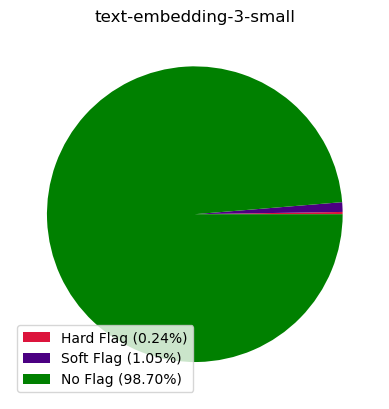

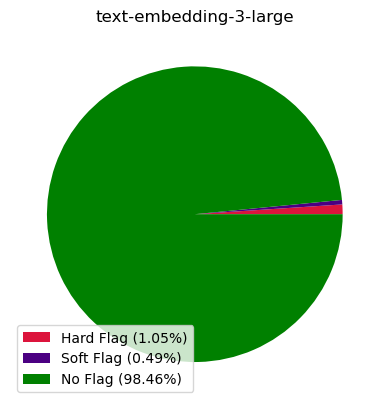

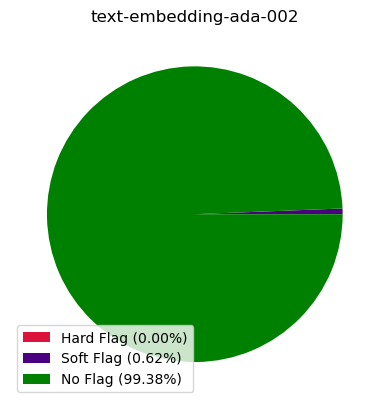

In [11]:
openai_models = openai_results['model_name'].unique().tolist()

for model in openai_models:
    df = openai_results[openai_results['model_name'] == model]

    no_flag = len(df[df['flag'] == 0])
    soft_flag = len(df[df['flag'] == 1])
    hard_flag = len(df[df['flag'] == 2])
    total = hard_flag + soft_flag + no_flag

    flag = [hard_flag, soft_flag, no_flag]
    labels = [f'Hard Flag ({(hard_flag / total) * 100:.2f}%)',
              f'Soft Flag ({(soft_flag / total) * 100:.2f}%)',
              f'No Flag ({(no_flag / total) * 100:.2f}%)']
    colors = ['crimson', 'indigo', 'green']

    plt.pie(flag, colors=colors)
    plt.title(model)
    plt.legend(labels=labels, loc='lower left')
    plt.show()

### OpenAI w/ Altered Thresholds

* $No\;Flag \; = \; \Delta < 1\%$
* $Soft\;Flag \; = \; 1\% \leq \Delta < 5\%$
* $Hard\;Flag \; = \; \Delta \geq 5\%$

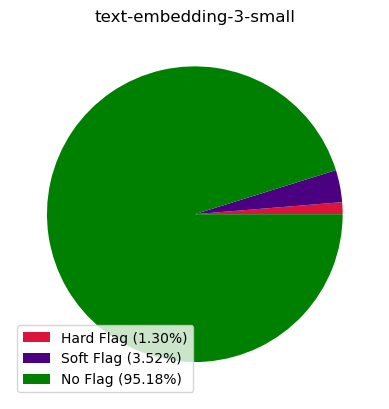

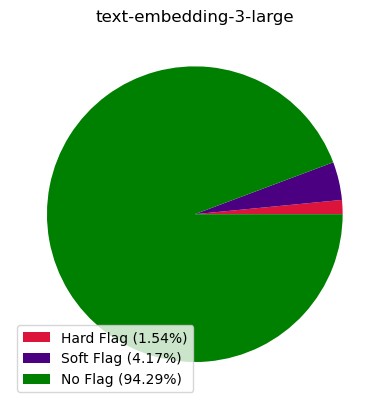

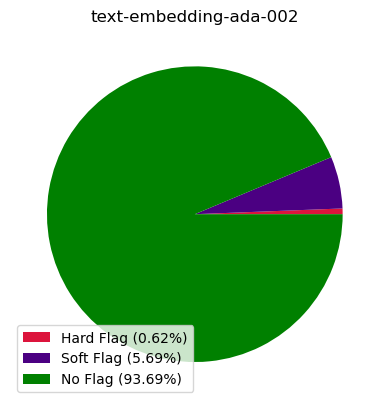

In [13]:
def altered_thresholds(row):
    if row['delta'] < 0.01:
        return 0
    elif row['delta'] >= 0.01 and row['delta'] < 0.05:
        return 1
    elif row['delta'] >= 0.05:
        return 2

openai_results_ = openai_results.copy()
openai_results_['new_flag'] = openai_results.apply(altered_thresholds, axis=1)

for model in openai_models:
    df = openai_results_[openai_results_['model_name'] == model]

    no_flag = len(df[df['new_flag'] == 0])
    soft_flag = len(df[df['new_flag'] == 1])
    hard_flag = len(df[df['new_flag'] == 2])
    total = hard_flag + soft_flag + no_flag

    flag = [hard_flag, soft_flag, no_flag]
    labels = [f'Hard Flag ({(hard_flag / total) * 100:.2f}%)',
              f'Soft Flag ({(soft_flag / total) * 100:.2f}%)',
              f'No Flag ({(no_flag / total) * 100:.2f}%)']
    colors = ['crimson', 'indigo', 'green']

    plt.pie(flag, colors=colors)
    plt.title(model)
    plt.legend(labels=labels, loc='lower left')
    plt.show()

## Top Candidate Shift

In [15]:
def top_candidate_shift(results, job, model):
    df = results[results['job_posting'] == job]
    df = df[df['model_name'] == model]

    baseline = df.sort_values(by='score_baseline', ascending=False).head(10)
    variant = df.sort_values(by='score_variant', ascending=False)

    baseline_top = baseline['resume_A'].tolist()
    variant_top = variant['resume_A_prime'].tolist()

    table = pd.DataFrame(columns=['Resume ID', 'Initial Position', 'New Position', 'Change'])

    resume_scores = {}

    for i, resume in enumerate(baseline_top):
        new_pos = variant_top.index(f'{resume}_prime')
        change = (i+1) - (new_pos+1)
        row = {'Resume ID': resume,
                'Initial Position': i+1,
                'New Position': new_pos+1,
                'Change': f'{change:+}'}
        table.loc[len(table)] = row

        score_baseline = df[df['resume_A'] == resume]['score_baseline'].iloc[0]
        score_variant = df[df['resume_A_prime'] == f'{resume}_prime']['score_variant'].iloc[0]
        resume_scores[resume] = (score_baseline, score_variant)

    resume_names = table['Resume ID'].tolist()
    plot = pd.DataFrame(resume_scores, index=['baseline', 'variant']).T

    x = np.arange(10)
    width = 0.35

    fig, ax = plt.subplots(layout='constrained')
    ax.bar(x - width/2, plot['baseline'], width, label='baseline', color='indigo')
    ax.bar(x + width/2, plot['variant'], width, label='variant', color='crimson')
    ax.set_title(f'Top Candidate Shift ({model})')
    ax.set_ylabel('Similarity Score')
    ax.set_xlabel('Resume ID')
    ax.set_xticks(x)
    ax.set_xticklabels(resume_names)
    ax.tick_params(axis='x', labelrotation=45)
    fig.legend(loc='outside right upper', frameon=False)

### Original

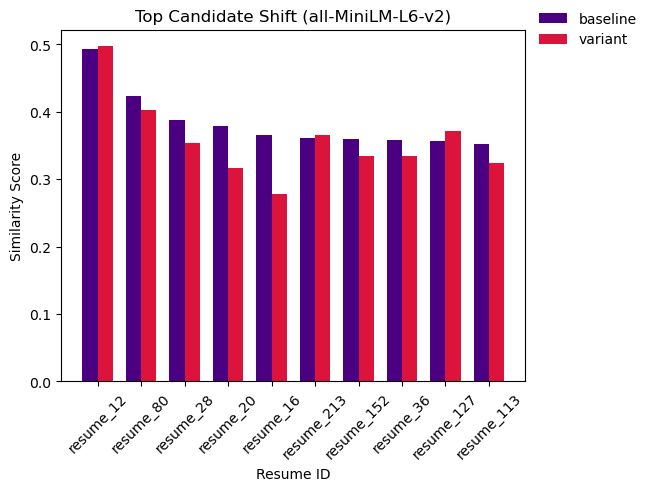

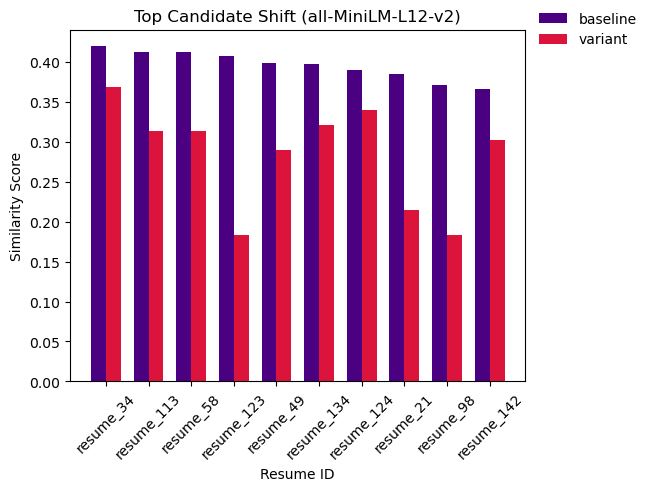

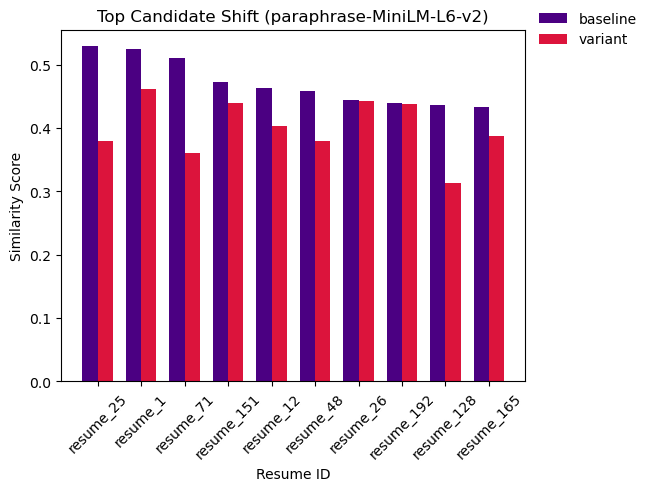

In [17]:
job = 'job_0'

for model in models:
    top_candidate_shift(results, job, model)

### OpenAI

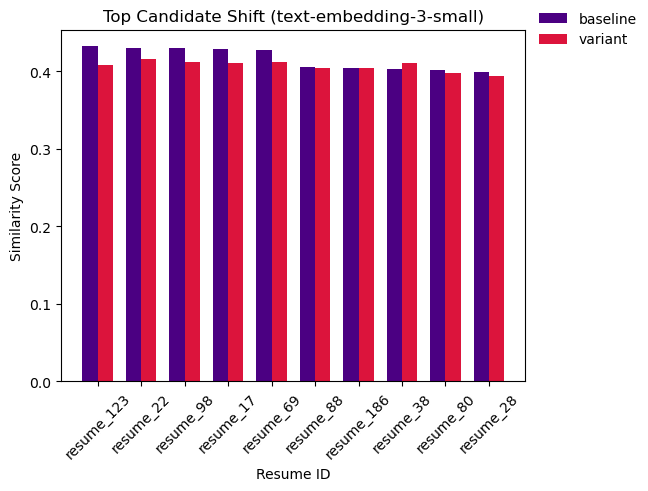

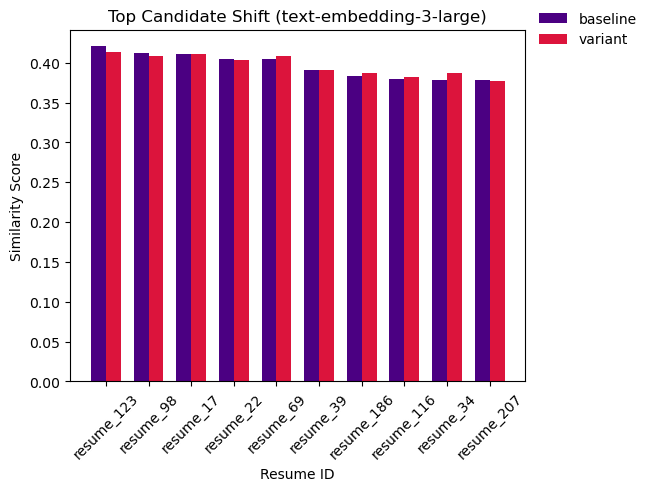

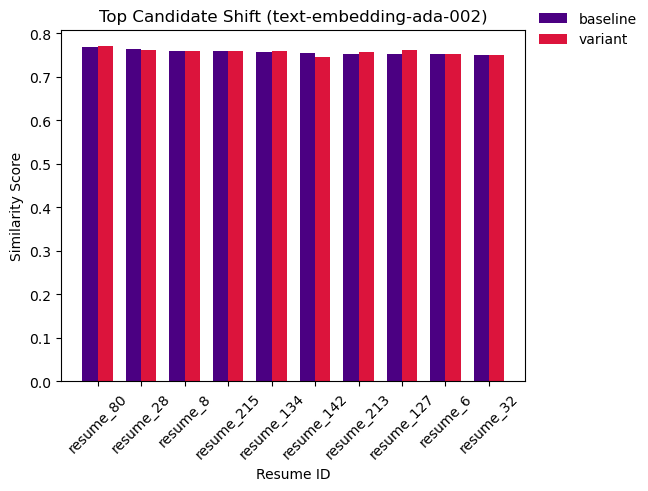

In [19]:
for model in openai_models:
    top_candidate_shift(openai_results, job, model)

## Top Candidate Overlap

In [21]:
from matplotlib_venn import venn3

def top_candidate_overlap(results, job):
    df = results[results['job_posting'] == job]
    model_names = results['model_name'].unique().tolist()

    model_0 = df[df['model_name'] == model_names[0]]
    model_0 = model_0.sort_values(by='score_baseline', ascending=False).head(10)
    model_1 = df[df['model_name'] == model_names[1]]
    model_1 = model_1.sort_values(by='score_baseline', ascending=False).head(10)
    model_2 = df[df['model_name'] == model_names[2]]
    model_2 = model_2.sort_values(by='score_baseline', ascending=False).head(10)

    r0 = set(model_0['resume_A'])
    r1 = set(model_1['resume_A'])
    r2 = set(model_2['resume_A'])

    labels = ('Model 0', 'Model 1', 'Model 2')
    colors = ('mediumslateblue', 'hotpink', 'lime')

    fig, ax = plt.subplots()
    venn3([r0, r1, r2], set_labels=labels, set_colors=colors)
    plt.show()

    print(f'Model 0 -- {model_names[0]}')
    print(f'Model 1 -- {model_names[1]}')
    print(f'Model 2 -- {model_names[2]}')

### Original

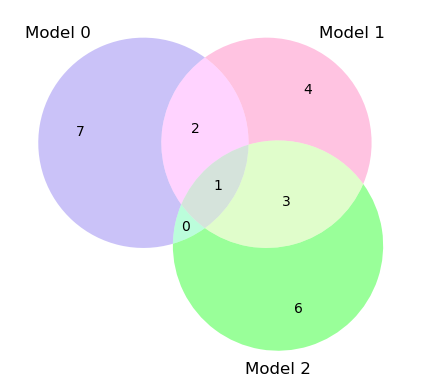

Model 0 -- all-MiniLM-L6-v2
Model 1 -- all-MiniLM-L12-v2
Model 2 -- paraphrase-MiniLM-L6-v2


In [23]:
job = 'job_1'

top_candidate_overlap(results, job)

### OpenAI

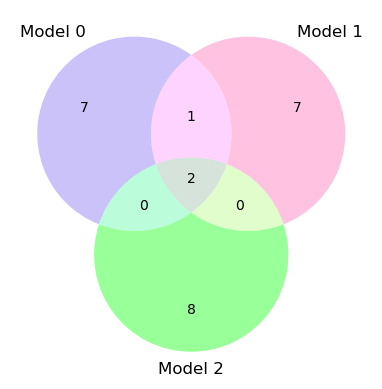

Model 0 -- text-embedding-3-small
Model 1 -- text-embedding-3-large
Model 2 -- text-embedding-ada-002


In [25]:
top_candidate_overlap(openai_results, job)

### END